In [1]:
!pip install pgmpy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 10.9 MB/s eta 0:00:00


True


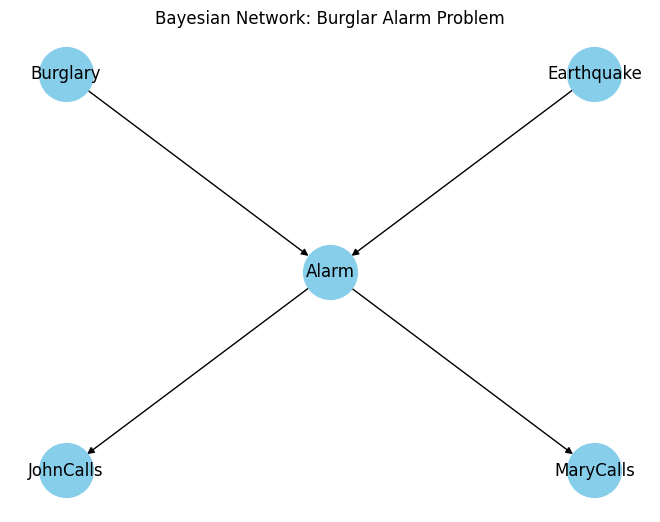

  0%|          | 0/9999 [00:00<?, ?it/s]


Approximate probabilities of Burglary:
Burglary
0    0.9995
1    0.0005
Name: proportion, dtype: float64


In [3]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.sampling import GibbsSampling
import networkx as nx
import matplotlib.pyplot as plt

model = DiscreteBayesianNetwork([
    ("Burglary", "Alarm"),
    ("Earthquake", "Alarm"),
    ("Alarm", "JohnCalls"),
    ("Alarm", "MaryCalls")
])

cpd_b = TabularCPD("Burglary", 2, [[0.999], [0.001]])
cpd_e = TabularCPD("Earthquake", 2, [[0.998], [0.002]])

cpd_a = TabularCPD(
    "Alarm", 2,
    [[0.999, 0.71, 0.06, 0.05],
     [0.001, 0.29, 0.94, 0.95]],
    evidence=["Burglary", "Earthquake"],
    evidence_card=[2, 2]
)

cpd_j = TabularCPD(
    "JohnCalls", 2,
    [[0.95, 0.1],
     [0.05, 0.9]],
    evidence=["Alarm"],
    evidence_card=[2]
)

cpd_m = TabularCPD(
    "MaryCalls", 2,
    [[0.1, 0.7],
     [0.9, 0.3]],
    evidence=["Alarm"],
    evidence_card=[2]
)

model.add_cpds(cpd_b, cpd_e, cpd_a, cpd_j, cpd_m)

print(model.check_model())

G = nx.DiGraph(model.edges())
pos = {
    "Burglary": (0, 0),
    "Earthquake": (2, 0),
    "Alarm": (1, -2),
    "JohnCalls": (0, -4),
    "MaryCalls": (2, -4),
}

nx.draw(G, pos, with_labels=True, node_size=1500, node_color="skyblue", arrows=True)
plt.title("Bayesian Network: Burglar Alarm Problem")
plt.axis("off")
plt.show()

samples = GibbsSampling(model).sample(size=10000)

print("\nApproximate probabilities of Burglary:")
print(samples["Burglary"].value_counts(normalize=True))
